# VIA Service Reliability — 5 Most Frequent Routes (Nov 17–23, 2025)

Measures schedule adherence for VIA's five highest-frequency routes using GTFS-RT vehicle position data joined to static GTFS stop times. Arrival deviation (actual minus scheduled, in minutes) is computed per stop visit, filtered to a ±90-minute window, and summarized by route and day of week.

## 1. Imports

In [21]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from dotenv import load_dotenv
import os

## 2. Load Data

Loads GTFS-RT vehicle positions from SQLite and static GTFS files (trips, stop times, calendar).

In [22]:
load_dotenv()
db_path = os.getenv("DB_PATH")
gtfs_path = os.getenv("GTFS_PATH")

def run_query(query):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(query, conn)

# Static GTFS
trips      = pd.read_csv(f'{gtfs_path}/trips.txt')
stop_times = pd.read_csv(f'{gtfs_path}/stop_times.txt')
calendar   = pd.read_csv(f'{gtfs_path}/calendar.txt')

# Cast to string to ensure data types match
trips['trip_id'] = trips['trip_id'].astype(str)
trips['route_id'] = trips['route_id'].astype(str)
trips['service_id'] = trips['service_id'].astype(str)
stop_times['trip_id'] = stop_times['trip_id'].astype(str)
calendar['service_id'] = calendar['service_id'].astype(str)
stop_times['stop_id'] = stop_times['stop_id'].astype(str)

# GTFS-RT vehicle positions — Nov 17–23 2025
df = run_query("""
    SELECT trip_id, route_id, stop_id, feed_timestamp, bearing
    FROM vehicle_positions
    WHERE feed_timestamp >= '2025-11-17'
      AND feed_timestamp <  '2025-11-24'
""")

# Drop records with no trip assignment (vehicles at yard) or no bearing
df = df.dropna(subset=['trip_id', 'bearing'])

# Cast to string
df['stop_id'] = df['stop_id'].astype(str)

## 3. Identify 5 Most Frequent Routes

In [23]:
frequent = trips.groupby('route_id')['trip_id'].nunique().sort_values(ascending=False)
print(frequent.head(10))

target_routes = ['100', '103', '102', '10', '20']

route_id
103    430
10     408
102    384
100    364
20     352
76     289
3      278
552    274
28     271
4      270
Name: trip_id, dtype: int64


## 4. Prepare Static Reference Data

Unpivots the calendar to one row per service/day combination, and filters stop times to remove late-night trips (hour ≥ 24) that would cause datetime parsing issues.

In [24]:
# Unpivot calendar: one row per service_id × day_of_week
day_map = {'monday': 0, 'tuesday': 1, 'wednesday': 2, 'thursday': 3,
           'friday': 4, 'saturday': 5, 'sunday': 6}

calendar_long = calendar.melt(
    id_vars=['service_id'],
    value_vars=day_map.keys(),
    var_name='day_name',
    value_name='runs_on_day'
)
calendar_long = calendar_long[calendar_long['runs_on_day'] == 1]
calendar_long['dayofweek'] = calendar_long['day_name'].map(day_map)

# Filter out late-night service
stop_limit = stop_times[stop_times['arrival_time'].str.split(':').str[0].astype(int) < 24]

# Join route_id in from trips
stop_limit = stop_limit.merge(
    trips[['trip_id', 'route_id', 'service_id']].drop_duplicates(),
    on='trip_id', how='left'
)

static_cols = ['service_id', 'route_id', 'trip_id', 'stop_id', 'stop_sequence', 'arrival_time', 'departure_time']
static = stop_limit[static_cols]

## 5. Route Analysis Function

For each route:
1. Filter GTFS-RT records to the analysis week
2. Collapse repeated position pings per trip/stop to a single arrival (min timestamp) and departure (max)
3. Convert UTC to CST
4. Join to calendar to get `service_id` by day of week
5. Merge to static stop times to get scheduled arrival
6. Compute `arrival_deviation` in minutes; filter to ±90-minute window

In [25]:
def analyze_route(route_id, rt_df, stop_times_df):
    # Filter for our routes
    route = rt_df[rt_df['route_id'] == route_id].copy().reset_index()
    route['feed_timestamp'] = pd.to_datetime(route['feed_timestamp'])

    # Filter for one week
    start_date = pd.to_datetime('2025-11-17').date()
    end_date = pd.to_datetime('2025-11-23').date()
    route = route[route['feed_timestamp'].dt.date.between(start_date, end_date)]

    # Set arrival and departure
    route = route.groupby(['trip_id', 'stop_id']).agg(route_id=('route_id', 'first'), arrival=('feed_timestamp', 'min'), departure=('feed_timestamp', 'max')).reset_index()

    # convert arrival and departure to correct timezones
    route['arrival'] = route['arrival'].dt.tz_localize('UTC').dt.tz_convert('America/Chicago')
    route['arrival'] = route['arrival'].dt.tz_localize(None)
    route['departure'] = route['departure'].dt.tz_localize('UTC').dt.tz_convert('America/Chicago')
    route['departure'] = route['departure'].dt.tz_localize(None)

    # For each of my dates, need to check what day of the week it is and which service id that joins to
    route['dayofweek'] = route['arrival'].dt.dayofweek

    # Join our data to calendar data
    route = pd.merge(route, calendar_long[['dayofweek', 'service_id']], how='left', on='dayofweek')

    # convert back to day name for readability
    route['dayofweek'] = route['arrival'].dt.day_name()

    # Merge routes to static data
    summary = route.merge(stop_times_df, how='left', on=['route_id', 'trip_id', 'stop_id', 'service_id'])
    summary = summary.sort_values(['arrival','trip_id', 'stop_id'], ascending=[True, True, True])
    summary = summary.dropna(subset='arrival_time')

    # Adding date to arrival and departure times so we can conver to dt
    summary['service_date'] = summary['arrival'].dt.date.astype(str)
    summary['arrival_time'] = pd.to_datetime(summary['service_date'] + ' ' + summary['arrival_time'])
    summary['departure_time'] = pd.to_datetime(summary['service_date'] + ' ' + summary['departure_time'])

    # Calculate deviation
    summary['arrival_deviation'] = (summary['arrival'] - summary['arrival_time']).dt.total_seconds() / 60

    # Remove rows outside of 90 minute threshold
    summary = summary[(summary['arrival_deviation'] <= 90) & (summary['arrival_deviation'] >= -90)]

    return summary

## 6. Run Analysis Across All 5 Routes

In [26]:
routes = ['100', '103', '102', '10', '20']
results = {r: analyze_route(r, df, static) for r in routes}

# Summary: mean deviation, std, n per route
for route_id, df_route in results.items():
    print(f"Route {route_id}: mean={df_route['arrival_deviation'].mean():.2f} min, "
          f"std={df_route['arrival_deviation'].std():.2f}, n={len(df_route)}")

Route 100: mean=0.94 min, std=4.21, n=6716
Route 103: mean=1.34 min, std=4.65, n=13324
Route 102: mean=1.06 min, std=4.71, n=8414
Route 10: mean=2.41 min, std=4.78, n=15941
Route 20: mean=2.04 min, std=4.22, n=20005


## 7. On-Time Performance Summary

In [27]:
# On-time rate per route (within ±5 minutes)
for route_id, df_route in results.items():
    on_time = (df_route['arrival_deviation'].abs() <= 5).mean() * 100
    print(f"Route {route_id}: {on_time:.1f}% on time")

# By-day breakdown for Route 100
print('\n--- Route 100 by day ---')
print(results['100'].groupby('dayofweek')['arrival_deviation'].agg(['mean', 'std', 'count']))

Route 100: 82.7% on time
Route 103: 83.3% on time
Route 102: 80.8% on time
Route 10: 82.5% on time
Route 20: 82.9% on time

--- Route 100 by day ---
               mean       std  count
dayofweek                           
Friday    -2.600000       NaN      1
Monday     0.370146  4.220275   2462
Saturday   1.444429  4.125506   2229
Sunday     1.151589  3.978112   1930
Thursday   1.335714  3.330060      7
Tuesday   -0.350000  7.480921     73
Wednesday -0.572619  7.786690     14


## 8. On-Time Heatmap — Route × Day

Percentage of stop visits within ±5 minutes of scheduled arrival.

dayofweek     Monday    Tuesday  Wednesday    Thursday      Friday   Saturday  \
route_id                                                                        
10         86.047498  88.167939  80.263158   80.000000   89.247312  77.458275   
100        84.565394  67.123288  50.000000  100.000000  100.000000  80.035891   
102        84.753735  80.519481  80.952381   70.000000  100.000000  76.011681   
103        83.963751  74.503311  68.518519   79.310345   78.571429  79.916112   
20         84.590467  76.164754  73.568282   74.369748   76.363636  79.304317   

dayofweek     Sunday  
route_id              
10         83.229814  
100        84.145078  
102        79.683973  
103        87.118019  
20         87.694817  


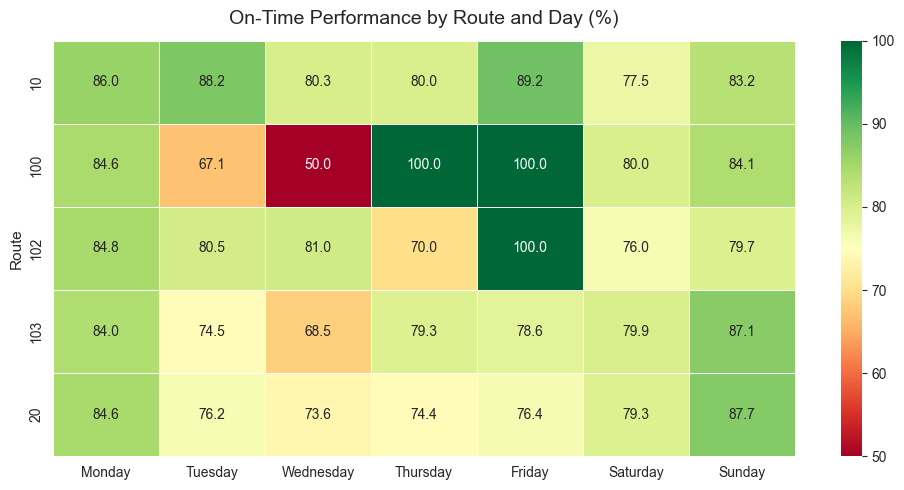

In [28]:
all_routes = pd.concat(results.values())
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = (
    all_routes
    .groupby(['route_id', 'dayofweek'])['arrival_deviation']
    .apply(lambda x: (x.abs() <= 5).mean() * 100)
    .unstack()[day_order]
)
print(pivot)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=50, vmax=100, ax=ax, linewidths=0.5
)
ax.set_title('On-Time Performance by Route and Day (%)', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Route', fontsize=11)
plt.tight_layout()
plt.show()